# Quartic Double-Well Potential

This notebook studies the one-dimensional **quartic double-well potential**

$$
V(x) = ax^4 - bx^2
$$
which is a simple model for **tunnelling** between two classically allowed regions.

When $a > 0$ and $b > 0$, the $x^4$ term keeps the particle bound, while the $-bx^2$ term creates two minima.
This gives a potential with **two wells** separated by a barrier near \(x=0\).

Our goal is to:
- build the Hamiltonian numerically,
- solve for the lowest eigenvalues and eigenfunctions,
- plot the wavefunctions on top of the potential, and
- understand how the lowest two states are related to tunnelling.

## Schrödinger Equation

In atomic units ($\hbar = m = 1$), the Hamiltonian is

$$
\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + V(x),
$$

with

$$
V(x) = ax^4 - bx^2.
$$

We will solve this equation on a grid using a **finite-difference approximation** for the second derivative.

For a grid spacing $\Delta x$, the kinetic-energy operator is approximated by

$$
-\frac{1}{2}\frac{d^2\psi}{dx^2}
\approx
-\frac{1}{2}\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{(\Delta x)^2}.
$$

This turns the Schrödinger equation into a matrix eigenvalue problem.

## Why this is a double well

To locate the stationary points of the potential, we differentiate:

$$
\frac{dV}{dx} = 4ax^3 - 2bx = 2x(2ax^2 - b).
$$

So the stationary points are at

$$
x = 0, \qquad x = \pm \sqrt{\frac{b}{2a}}.
$$

For $a > 0$ and $b > 0$:

- $x = 0$ is the **barrier top**  
- $x = \pm \sqrt{\frac{b}{2a}}$ are the **two minima**

The depth and separation of the wells depend on the values of $a$ and $b$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

plt.rcParams["figure.dpi"] = 130

In [2]:
def quartic_potential(x, a=0.02, b=1.0):
    """Return the quartic double-well potential V(x) = a x^4 - b x^2."""
    return a * x**4 - b * x**2

def kinetic_energy_matrix(x):
    """Construct the finite-difference kinetic-energy matrix."""
    dx = x[1] - x[0]
    n = len(x)
    main = np.full(n, 1.0 / dx**2)
    off = np.full(n - 1, -0.5 / dx**2)
    T = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)
    return T

def hamiltonian_matrix(x, a=0.02, b=1.0):
    """Construct H = T + V on the grid x."""
    T = kinetic_energy_matrix(x)
    V = np.diag(quartic_potential(x, a=a, b=b))
    return T + V

def normalize_wavefunction(psi, x):
    """Normalize a wavefunction on the grid x."""
    norm = np.sqrt(np.trapz(np.abs(psi)**2, x))
    return psi / norm

def solve_double_well(x, a=0.02, b=1.0, nstates=6):
    """Solve for the lowest-energy eigenstates of the quartic double well."""
    H = hamiltonian_matrix(x, a=a, b=b)
    eigvals, eigvecs = eigh(H)

    eigvals = eigvals[:nstates]
    eigvecs = eigvecs[:, :nstates]

    for i in range(nstates):
        eigvecs[:, i] = normalize_wavefunction(eigvecs[:, i], x)

    return eigvals, eigvecs

In [3]:
# Define a grid and solve the problem for one choice of parameters.
x = np.linspace(-8, 8, 800)

a = 0.02
b = 1.0

energies, wavefunctions = solve_double_well(x, a=a, b=b, nstates=6)

print("Lowest six energies:")
for i, E in enumerate(energies):
    print(f"n = {i}: E = {E:.6f}")

Lowest six energies:
n = 0: E = -11.510286
n = 1: E = -11.510286
n = 2: E = -9.573803
n = 3: E = -9.573803
n = 4: E = -7.706949
n = 5: E = -7.706949


/tmp/ipykernel_2618/3806144052.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi)**2, x))


# Physical Interpretation: Connection to Real Systems

The double-well potential models real systems:


*   Chemical reactions: wells = reactant & product

*   Electron transfer: wells = two sites

*   Proton transfer: tunneling in hydrogen bonds

The barrier represents activation energy.



## Plotting the potential and eigenfunctions

To compare the shapes of the wavefunctions with the potential, it is useful to plot
the wavefunctions after shifting them upward by their eigenenergies.

This does **not** change the physics. It only makes the figure easier to read.

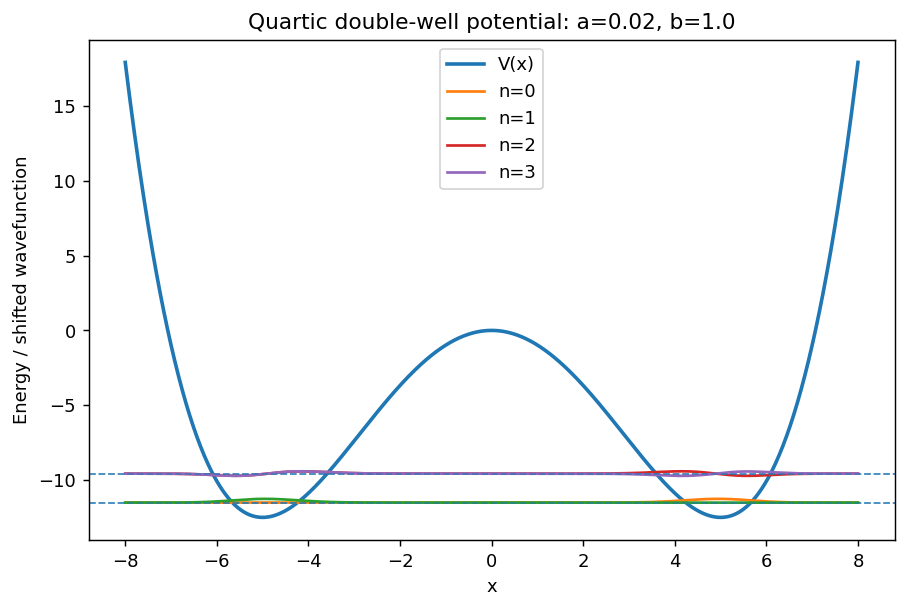

In [4]:
def plot_states(x, energies, wavefunctions, a=0.02, b=1.0, nplot=4, scale=0.28):
    """Plot the potential and the lowest few eigenfunctions."""
    Vx = quartic_potential(x, a=a, b=b)

    plt.figure(figsize=(8, 5))
    plt.plot(x, Vx, lw=2, label="V(x)")

    for n in range(nplot):
        psi = wavefunctions[:, n]
        plt.plot(x, energies[n] + scale * psi, label=f"n={n}")
        plt.axhline(energies[n], ls="--", lw=1, alpha=0.6)

    plt.xlabel("x")
    plt.ylabel("Energy / shifted wavefunction")
    plt.title(f"Quartic double-well potential: a={a}, b={b}")
    plt.legend()
    plt.show()

plot_states(x, energies, wavefunctions, a=a, b=b, nplot=4)

## Probability densities

The quantity $|\psi(x)|^2$ gives the probability density.
For a symmetric double well:

- the **ground state** is symmetric,
- the **first excited state** is antisymmetric,
- the two lowest energies are often very close together.

That small energy difference is a signature of **quantum tunnelling** through the central barrier.

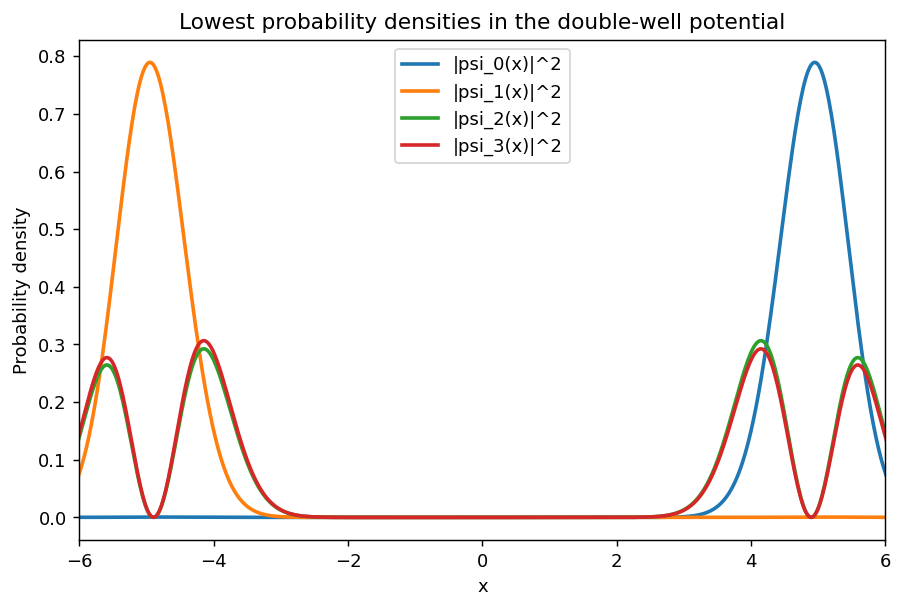

Energy splitting between the two lowest states: ΔE = 0.000000


In [5]:
plt.figure(figsize=(8, 5))
for n in range(4):
    plt.plot(x, np.abs(wavefunctions[:, n])**2, lw=2, label=f"|psi_{n}(x)|^2")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Lowest probability densities in the double-well potential")
plt.xlim(-6, 6)
plt.legend()
plt.show()

print(f"Energy splitting between the two lowest states: ΔE = {energies[1] - energies[0]:.6f}")

## Changing the barrier shape

The parameter $a$ controls how strongly the particle is confined at large $|x|$,  
while $b$ helps create the two minima.

A useful question is: **what happens to the lowest two energies when the barrier changes?**

Below, we vary $b$ while keeping $a$ fixed.

/tmp/ipykernel_2618/3806144052.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(np.abs(psi)**2, x))


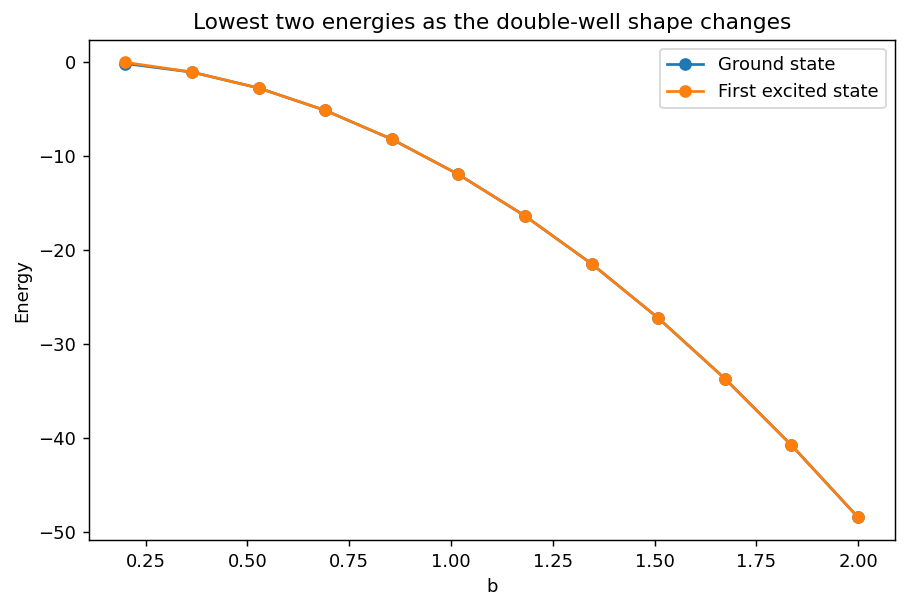

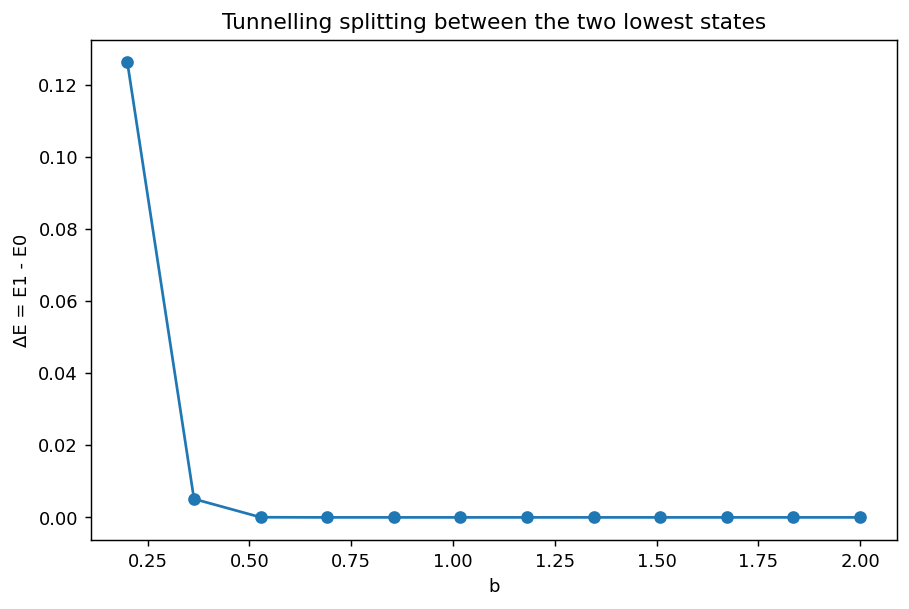

In [6]:
def compute_lowest_two_energies(x, a=0.02, b_values=None):
    if b_values is None:
        b_values = np.linspace(0.2, 2.0, 10)

    E0 = []
    E1 = []
    split = []

    for b in b_values:
        energies, _ = solve_double_well(x, a=a, b=b, nstates=2)
        E0.append(energies[0])
        E1.append(energies[1])
        split.append(energies[1] - energies[0])

    return np.array(b_values), np.array(E0), np.array(E1), np.array(split)

b_values, E0, E1, split = compute_lowest_two_energies(x, a=0.02, b_values=np.linspace(0.2, 2.0, 12))

plt.figure(figsize=(8, 5))
plt.plot(b_values, E0, "o-", label="Ground state")
plt.plot(b_values, E1, "o-", label="First excited state")
plt.xlabel("b")
plt.ylabel("Energy")
plt.title("Lowest two energies as the double-well shape changes")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(b_values, split, "o-")
plt.xlabel("b")
plt.ylabel("ΔE = E1 - E0")
plt.title("Tunnelling splitting between the two lowest states")
plt.show()

## Discussion

This notebook shows the main quantum features of a double-well system:

1. The quartic potential $V(x) = ax^4 - bx^2$ produces two minima for $a > 0$ and $b > 0$.
2. The Schrödinger equation can be solved numerically using a finite-difference Hamiltonian.
3. The two lowest states are close in energy because the particle can tunnel through the barrier.
4. As the barrier changes, the splitting $\Delta E = E_1 - E_0$ also changes.

Physically, the lowest two stationary states are spread over **both wells**, even though classically one might expect the particle to stay in just one well.

This is a direct consequence of quantum mechanics.